In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [6]:
df=pd.read_csv("Ice_cream selling data.csv")

In [7]:
df.head(4)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845


In [8]:
df.shape

(49, 2)

In [9]:
import seaborn as sns

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

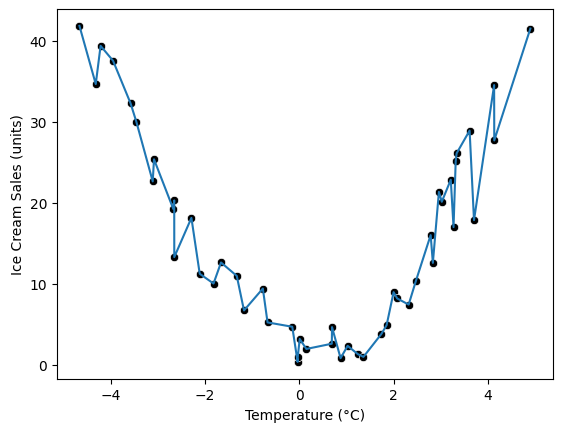

In [10]:
sns.lineplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'])
sns.scatterplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'],color="black")

In [19]:
x=df.iloc[:,0:1]
y=df.iloc[:,1:2]

In [ ]:
from sklearn.linear_model import train_test_split


In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

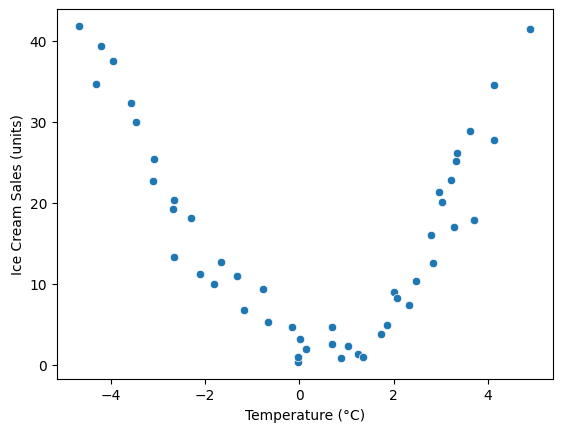

In [25]:
sns.scatterplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'])

In [ ]:
from sklearn.linear_model import LinearRegression

In [28]:
lr=LinearRegression()

In [29]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
lr.coef_

array([[-1.14658686]])

In [31]:
lr.intercept_

array([17.13921313])

In [32]:
from sklearn.metrics import mean_squared_error,r2_score


In [33]:
y_pred=lr.predict(x_test)

In [ ]:
print('MSE :',mean_squared_error(y_test,y_pred))
print('R2 Score :',r2_score(y_test,y_pred))

MSE : 149.32629119325185
R2 Score : -0.5751270190188227


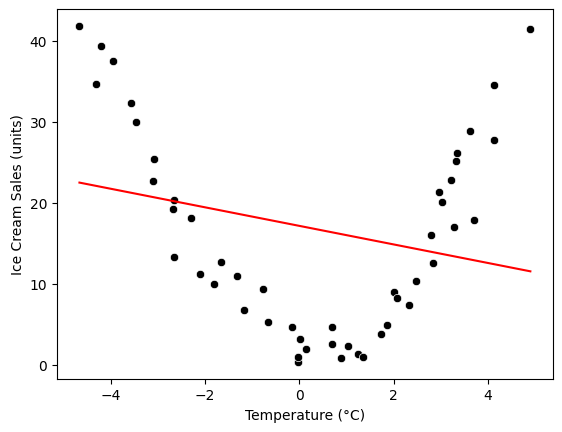

In [36]:
sns.scatterplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'],color="black")
plt.plot(df['Temperature (°C)'], lr.coef_[0] * df['Temperature (°C)'] + lr.intercept_, color='red')

In [37]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly=PolynomialFeatures(degree=10)

In [58]:
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.fit_transform(x_test)


In [59]:
x_train_poly.shape

(39, 3)

In [60]:
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [80]:
polylr=LinearRegression()

In [ ]:
polylr.fit(x_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
y_pred_poly=polylr.predict(x_test_poly)

In [75]:
from sklearn.metrics import mean_absolute_error

In [ ]:
print('MSE :',mean_squared_error(y_test,y_pred_poly))
print('R2 Score :',r2_score(y_test,y_pred_poly))
print('Mean error :',mean_absolute_error(y_test,y_pred_poly))

MSE : 14.878796440981484
R2 Score : 0.843055137193884
Mean error : 3.2299819836597274


In [ ]:
sns.scatterplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'],color="black")
plt.plot(df['Temperature (°C)'], lr.coef_[0] * df['Temperature (°C)'] + lr.intercept_, color='red')

In [70]:
coef = polylr.coef_.flatten()
intercept = polylr.intercept_.item()

eqn = f"y = {intercept:.2f} + {coef[1]:.2f}x + {coef[2]:.2f}x²"
print(eqn)

y = 2.77 + -0.71x + 1.87x²


c:\Users\rayph\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


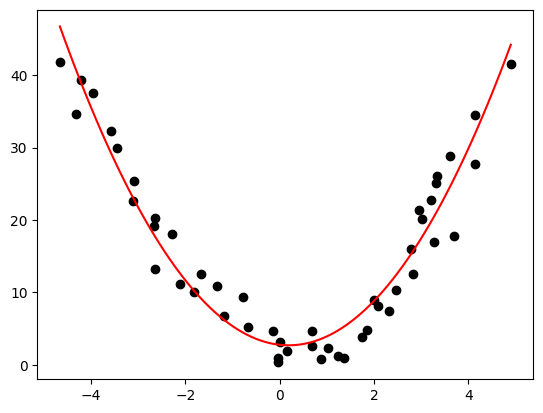

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(x, y, color="black")

x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)

plt.plot(x_range, polylr.predict(x_range_poly), color="red")


In [160]:
poly=PolynomialFeatures(degree=10)

In [161]:
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.fit_transform(x_test)


In [162]:
polylr=LinearRegression()

In [163]:
polylr.fit(x_train_poly,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [164]:
y_pred_poly=polylr.predict(x_test_poly)

In [165]:
print('MSE :',mean_squared_error(y_test,y_pred_poly))
print('R2 Score :',r2_score(y_test,y_pred_poly))
print('Mean error :',mean_absolute_error(y_test,y_pred_poly))

MSE : 24.335877575172262
R2 Score : 0.7432997364772135
Mean error : 3.2902597305990327


c:\Users\rayph\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


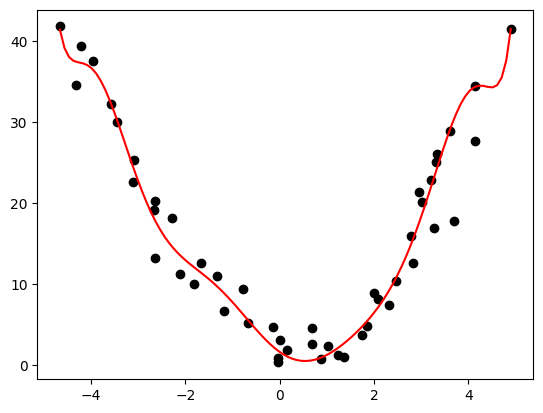

In [166]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(x, y, color="black")

x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)

plt.plot(x_range, polylr.predict(x_range_poly), color="red")